# Real-World Noise Augmentation

Generates a noise-augmented training dataset using the real-world noise bank
collected from an Arduino Nano 33 BLE Sense Rev2 mounted on a real vehicle.

**Augmentation strategy:**
1. Start from the original 970 training samples
2. Apply class-balancing (same multipliers as the synthetic augmentation)
3. For each augmented copy, apply a random waveform augmentation AND mix in
   real-world noise at a random SNR using operationally-relevant noise groups
4. Extract mel-spectrogram and MFCC features
5. Save as `train_noise_augmented.npz` (distinct from `train_augmented.npz`)

**Ablation conditions:**

| Condition | Training File | Samples | Description |
|-----------|--------------|---------|-------------|
| A (Baseline) | `train.npz` | 970 | Original, no augmentation |
| B (Synthetic Aug) | `train_augmented.npz` | 3,317 | Waveform augmentation + class balancing |
| C (Noise Aug) | `train_noise_augmented.npz` | ~3,317 | Waveform aug + class balancing + real-world noise injection |

In [1]:
import json
import sys
import time
from pathlib import Path

import numpy as np
from tqdm import tqdm

# Paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from augmentation import augment_waveform
from features import compute_log_mel_spectrogram, compute_mfcc, compute_normalization_stats
from preprocessing import preprocess_split

DATA_DIR = PROJECT_ROOT / 'data'
MEL_DIR = DATA_DIR / 'features' / 'mel_spectrograms'
MFCC_DIR = DATA_DIR / 'features' / 'mfcc'
NOISE_BANK_PATH = DATA_DIR / 'noise_bank' / 'noise_bank.npz'
NOISE_CONFIG_PATH = DATA_DIR / 'noise_bank' / 'noise_config.json'

RANDOM_STATE = 42
TARGET_SR = 16000
TARGET_PER_CLASS = 550

print(f'Project root: {PROJECT_ROOT}')

Project root: /home/robert/BDA602/Car_Sounds


## 1. Load Noise Bank and Configuration

In [2]:
# Load noise config
with open(NOISE_CONFIG_PATH) as f:
    noise_config = json.load(f)

# Load noise bank (numpy compressed archive)
noise_bank_data = np.load(str(NOISE_BANK_PATH), allow_pickle=True)
group_names = list(noise_bank_data['group_names'])

# Build noise bank dict: group_name -> array of waveforms (N, 24000)
noise_bank = {}
for group in group_names:
    noise_bank[group] = noise_bank_data[f'{group}_audio']

print('Noise bank loaded:')
for group, audio in noise_bank.items():
    print(f'  {group:25s}: {len(audio):3d} samples')

# Noise relevance mapping (operational state -> relevant noise groups)
noise_relevance = noise_config['noise_relevance']
snr_levels = noise_config['snr_levels_db']
print(f'\nSNR levels: {snr_levels} dB')
print(f'\nNoise relevance mapping:')
for state, groups in noise_relevance.items():
    total = sum(len(noise_bank[g]) for g in groups)
    print(f'  {state:10s} -> {total:3d} noise samples from: {", ".join(groups)}')

Noise bank loaded:
  engine_mechanical        : 103 samples
  hvac                     :  30 samples
  road_driving             :  60 samples
  cabin_driving            :  60 samples
  wind                     :  20 samples
  ambient_stationary       :  87 samples

SNR levels: [5, 10, 15, 20] dB

Noise relevance mapping:
  braking    -> 273 noise samples from: engine_mechanical, road_driving, cabin_driving, wind, hvac
  idle       -> 240 noise samples from: engine_mechanical, hvac, ambient_stationary, wind
  startup    -> 137 noise samples from: ambient_stationary, wind, hvac


## 2. Load Original Training Audio

In [3]:
manifest_path = DATA_DIR / 'splits' / 'train_manifest.csv'
audio_orig, labels_orig, file_paths_orig = preprocess_split(
    str(manifest_path), project_root=str(PROJECT_ROOT)
)

y_tier1 = labels_orig['tier1']
y_tier2 = labels_orig['tier2']
y_tier3 = labels_orig['tier3']
n_orig = len(audio_orig)

# Load tier definitions
with open(DATA_DIR / 'preprocessing_config.json') as f:
    tier_defs = json.load(f)['tier_definitions']
tier2_names = tier_defs['tier2']['names']

print(f'Original training set: {n_orig} samples')
print(f'\nTier 2 distribution:')
for i, name in enumerate(tier2_names):
    count = int((y_tier2 == i).sum())
    print(f'  {name:20s}: {count:4d}')

Preprocessing audio:   0%|          | 0/970 [00:00<?, ?it/s]/home/robert/BDA602/Car_Sounds/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Preprocessing audio: 100%|██████████| 970/970 [00:01<00:00, 597.68it/s] 


Original training set: 970 samples

Tier 2 distribution:
  Normal Braking      :   54
  Braking Fault       :   53
  Normal Idle         :  185
  Idle Fault          :  552
  Normal Start-Up     :   43
  Start-Up Fault      :   83


## 3. Define Noise Mixing Functions

In [4]:
# Map Tier 2 class indices to operational states for noise selection
TIER2_TO_STATE = {
    0: 'braking',   # Normal Braking
    1: 'braking',   # Braking Fault
    2: 'idle',      # Normal Idle
    3: 'idle',      # Idle Fault
    4: 'startup',   # Normal Start-Up
    5: 'startup',   # Start-Up Fault
}


def mix_noise_at_snr(signal, noise, snr_db):
    """Mix noise into signal at a target SNR (dB)."""
    signal_power = np.mean(signal ** 2)
    noise_power = np.mean(noise ** 2)
    if noise_power == 0 or signal_power == 0:
        return signal.copy()
    target_noise_power = signal_power / (10 ** (snr_db / 10))
    scale = np.sqrt(target_noise_power / noise_power)
    return signal + scale * noise


def get_random_noise(tier2_class, rng):
    """Select a random noise sample from operationally-relevant groups."""
    state = TIER2_TO_STATE[tier2_class]
    relevant_groups = noise_relevance[state]
    
    # Pool all relevant noise samples
    pool = []
    for group in relevant_groups:
        pool.append(noise_bank[group])
    pool = np.concatenate(pool, axis=0)
    
    # Pick one at random
    idx = rng.integers(0, len(pool))
    return pool[idx]


def augment_with_noise(y, tier2_class, sr, rng):
    """Apply waveform augmentation AND real-world noise injection.
    
    Pipeline:
    1. Apply standard waveform augmentation (time shift, gain, etc.)
    2. Select a noise sample from operationally-relevant groups
    3. Mix at a random SNR from the configured levels
    """
    # Step 1: Standard waveform augmentation
    y_aug = augment_waveform(y, sr=sr, rng=rng)
    
    # Step 2: Real-world noise injection (always applied)
    noise_sample = get_random_noise(tier2_class, rng)
    snr_db = rng.choice(snr_levels)
    y_aug = mix_noise_at_snr(y_aug, noise_sample, snr_db)
    
    return y_aug.astype(np.float32)


print('Noise mixing functions defined.')
print(f'\nOperational state mapping:')
for cls, state in TIER2_TO_STATE.items():
    groups = noise_relevance[state]
    pool_size = sum(len(noise_bank[g]) for g in groups)
    print(f'  {tier2_names[cls]:20s} -> {state:8s} -> {pool_size:3d} noise samples')

Noise mixing functions defined.

Operational state mapping:
  Normal Braking       -> braking  -> 273 noise samples
  Braking Fault        -> braking  -> 273 noise samples
  Normal Idle          -> idle     -> 240 noise samples
  Idle Fault           -> idle     -> 240 noise samples
  Normal Start-Up      -> startup  -> 137 noise samples
  Start-Up Fault       -> startup  -> 137 noise samples


## 4. Compute Class-Balancing Multipliers

Same strategy as the synthetic augmentation: bring every Tier 2 class
to ~550 samples.

In [5]:
def compute_multipliers(y_tier2, num_classes=6, target=TARGET_PER_CLASS):
    multipliers = {}
    for cls in range(num_classes):
        count = int((y_tier2 == cls).sum())
        if count >= target:
            multipliers[cls] = 0
        else:
            needed = target - count
            multipliers[cls] = max(1, round(needed / count))
    return multipliers

multipliers = compute_multipliers(y_tier2)

print(f'{"Class":<20s} {"Original":>8s} {"Mult":>5s} {"Augmented":>10s} {"Total":>7s}')
print('-' * 55)
total_aug = 0
for cls in range(6):
    count = int((y_tier2 == cls).sum())
    mult = multipliers[cls]
    n_aug = count * mult
    total_aug += n_aug
    print(f'{tier2_names[cls]:<20s} {count:>8d} {mult:>5d}x {n_aug:>10d} {count + n_aug:>7d}')

print(f'\nTotal augmented samples to generate: {total_aug}')
print(f'Final training set size: {n_orig + total_aug}')

Class                Original  Mult  Augmented   Total
-------------------------------------------------------
Normal Braking             54     9x        486     540
Braking Fault              53     9x        477     530
Normal Idle               185     2x        370     555
Idle Fault                552     0x          0     552
Normal Start-Up            43    12x        516     559
Start-Up Fault             83     6x        498     581

Total augmented samples to generate: 2347
Final training set size: 3317


## 5. Generate Noise-Augmented Waveforms

In [6]:
t0 = time.time()

aug_audio_list = []
aug_tier1_list = []
aug_tier2_list = []
aug_tier3_list = []
aug_paths_list = []

rng = np.random.default_rng(RANDOM_STATE)

for i in tqdm(range(n_orig), desc='Augmenting with noise'):
    cls = y_tier2[i]
    mult = multipliers[cls]
    for j in range(mult):
        # Each augmented copy gets a unique but reproducible seed
        # Offset by 10000 to avoid overlap with synthetic augmentation seeds
        aug_rng = np.random.default_rng(RANDOM_STATE + i * 100 + j + 10000)
        y_aug = augment_with_noise(audio_orig[i], cls, TARGET_SR, aug_rng)
        aug_audio_list.append(y_aug)
        aug_tier1_list.append(y_tier1[i])
        aug_tier2_list.append(y_tier2[i])
        aug_tier3_list.append(y_tier3[i])
        aug_paths_list.append(f'noise_augmented/{file_paths_orig[i]}::noise_aug{j}')

aug_audio = np.stack(aug_audio_list, axis=0).astype(np.float32)
elapsed_aug = time.time() - t0

print(f'\nGenerated {len(aug_audio)} noise-augmented waveforms in {elapsed_aug:.1f}s')

# Combine original + augmented
all_audio = np.concatenate([audio_orig, aug_audio], axis=0)
all_tier1 = np.concatenate([y_tier1, np.array(aug_tier1_list, dtype=np.int32)])
all_tier2 = np.concatenate([y_tier2, np.array(aug_tier2_list, dtype=np.int32)])
all_tier3 = np.concatenate([y_tier3, np.array(aug_tier3_list, dtype=np.int32)])
all_paths = file_paths_orig + aug_paths_list

print(f'Combined training set: {len(all_audio)} samples')
print(f'\nFinal Tier 2 distribution:')
for cls in range(6):
    count = int((all_tier2 == cls).sum())
    print(f'  {tier2_names[cls]:<20s}: {count}')

# Free memory
del aug_audio, aug_audio_list

Augmenting with noise: 100%|██████████| 970/970 [00:14<00:00, 67.48it/s] 



Generated 2347 noise-augmented waveforms in 14.6s
Combined training set: 3317 samples

Final Tier 2 distribution:
  Normal Braking      : 540
  Braking Fault       : 530
  Normal Idle         : 555
  Idle Fault          : 552
  Normal Start-Up     : 559
  Start-Up Fault      : 581


## 6. Verify Augmented Waveforms

Quick visual check: compare an original sample with its noise-augmented version.

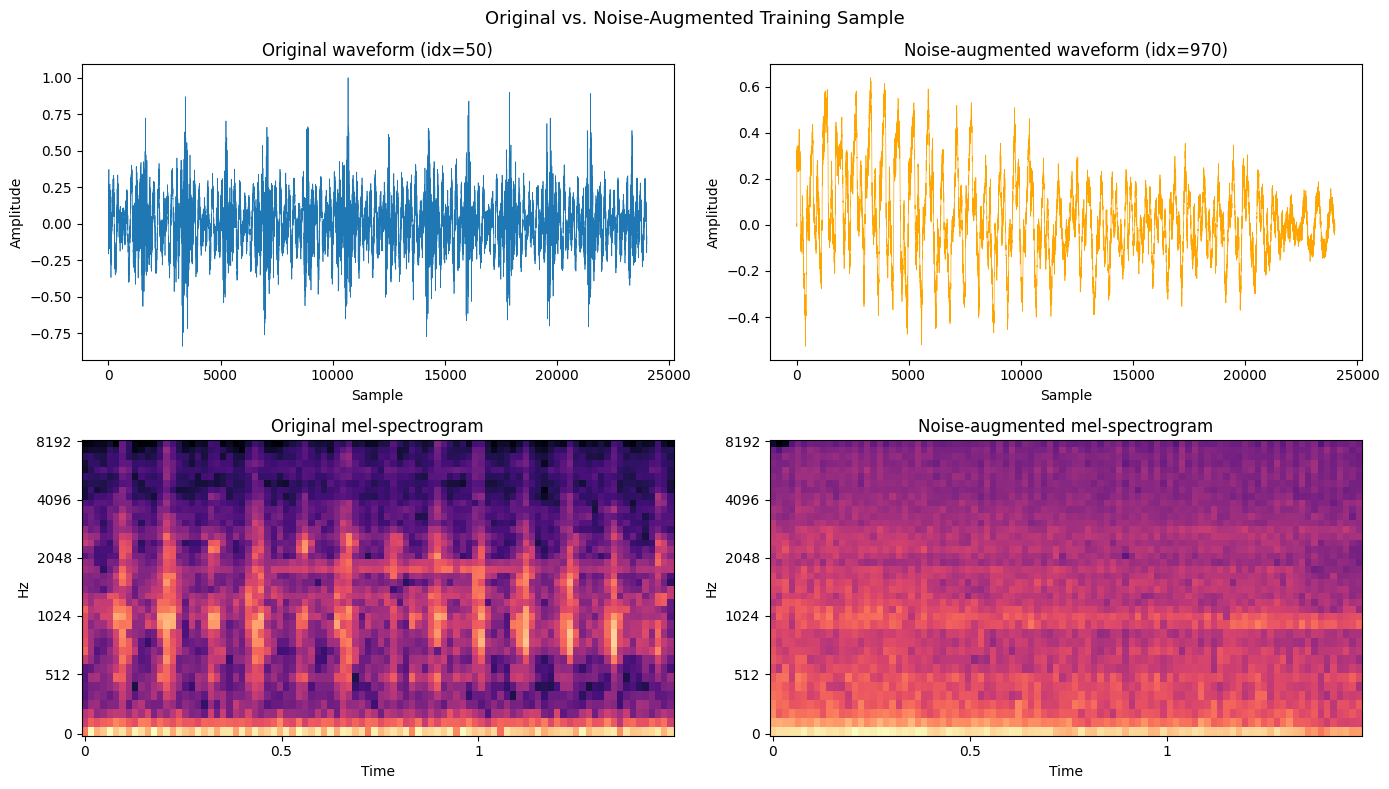

In [7]:
import matplotlib.pyplot as plt
import librosa
import librosa.display

# Find the first augmented sample (original samples come first)
orig_idx = 50
aug_idx = n_orig  # first augmented sample

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Original waveform
axes[0, 0].plot(all_audio[orig_idx], linewidth=0.5)
axes[0, 0].set_title(f'Original waveform (idx={orig_idx})')
axes[0, 0].set_xlabel('Sample')
axes[0, 0].set_ylabel('Amplitude')

# Augmented waveform
axes[0, 1].plot(all_audio[aug_idx], linewidth=0.5, color='orange')
axes[0, 1].set_title(f'Noise-augmented waveform (idx={aug_idx})')
axes[0, 1].set_xlabel('Sample')
axes[0, 1].set_ylabel('Amplitude')

# Original mel-spectrogram
S_orig = librosa.feature.melspectrogram(y=all_audio[orig_idx], sr=16000,
                                        n_fft=512, hop_length=256, n_mels=40, fmin=20, fmax=8000)
librosa.display.specshow(librosa.power_to_db(S_orig, ref=np.max), sr=16000, hop_length=256,
                         x_axis='time', y_axis='mel', fmin=20, fmax=8000, ax=axes[1, 0], cmap='magma')
axes[1, 0].set_title('Original mel-spectrogram')

# Augmented mel-spectrogram
S_aug = librosa.feature.melspectrogram(y=all_audio[aug_idx], sr=16000,
                                       n_fft=512, hop_length=256, n_mels=40, fmin=20, fmax=8000)
librosa.display.specshow(librosa.power_to_db(S_aug, ref=np.max), sr=16000, hop_length=256,
                         x_axis='time', y_axis='mel', fmin=20, fmax=8000, ax=axes[1, 1], cmap='magma')
axes[1, 1].set_title('Noise-augmented mel-spectrogram')

fig.suptitle('Original vs. Noise-Augmented Training Sample', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Extract Features

In [8]:
t0 = time.time()

# Mel-spectrograms
print('Extracting mel-spectrograms...')
mel_specs = []
for i in tqdm(range(len(all_audio)), desc='Mel-spectrograms'):
    spec = compute_log_mel_spectrogram(all_audio[i], sr=TARGET_SR)
    mel_specs.append(spec)
mel_specs = np.stack(mel_specs, axis=0).astype(np.float32)
print(f'  Mel-spectrograms: {mel_specs.shape}')

# MFCCs
print('\nExtracting MFCCs...')
mfccs = []
for i in tqdm(range(len(all_audio)), desc='MFCCs'):
    mfcc = compute_mfcc(all_audio[i], sr=TARGET_SR)
    mfccs.append(mfcc)
mfccs = np.stack(mfccs, axis=0).astype(np.float32)
print(f'  MFCCs: {mfccs.shape}')

elapsed_feat = time.time() - t0
print(f'\nFeature extraction completed in {elapsed_feat:.1f}s')

del all_audio  # free waveform memory

Extracting mel-spectrograms...


Mel-spectrograms: 100%|██████████| 3317/3317 [00:22<00:00, 149.79it/s]


  Mel-spectrograms: (3317, 40, 92)

Extracting MFCCs...


MFCCs: 100%|██████████| 3317/3317 [00:24<00:00, 138.04it/s]

  MFCCs: (3317, 92, 13)

Feature extraction completed in 46.3s


## 8. Save Noise-Augmented Dataset

Saved with the `_noise_augmented` suffix to clearly distinguish from:
- `train.npz` (original, 970 samples)
- `train_augmented.npz` (synthetic augmentation only, 3,317 samples)

In [9]:
# Save mel-spectrograms
mel_path = MEL_DIR / 'train_noise_augmented.npz'
np.savez_compressed(
    mel_path,
    X=mel_specs,
    y_tier1=all_tier1, y_tier2=all_tier2, y_tier3=all_tier3,
    file_paths=np.array(all_paths, dtype=object),
)
size_mb = mel_path.stat().st_size / (1024 * 1024)
print(f'Saved: {mel_path.relative_to(PROJECT_ROOT)} ({size_mb:.1f} MB)')

# Save MFCCs
mfcc_path = MFCC_DIR / 'train_noise_augmented.npz'
np.savez_compressed(
    mfcc_path,
    X=mfccs,
    y_tier1=all_tier1, y_tier2=all_tier2, y_tier3=all_tier3,
    file_paths=np.array(all_paths, dtype=object),
)
size_mb = mfcc_path.stat().st_size / (1024 * 1024)
print(f'Saved: {mfcc_path.relative_to(PROJECT_ROOT)} ({size_mb:.1f} MB)')

Saved: data/features/mel_spectrograms/train_noise_augmented.npz (40.6 MB)
Saved: data/features/mfcc/train_noise_augmented.npz (14.1 MB)


In [10]:
# Compute and save normalization stats from the noise-augmented training set
print('Computing normalization stats from noise-augmented training set...')
mel_stats = compute_normalization_stats(mel_specs, feature_type='mel')
mfcc_stats = compute_normalization_stats(mfccs, feature_type='mfcc')

stats_path = DATA_DIR / 'normalization_stats_noise_augmented.npz'
np.savez(
    stats_path,
    mel_mean=mel_stats['mean'], mel_std=mel_stats['std'],
    mfcc_mean=mfcc_stats['mean'], mfcc_std=mfcc_stats['std'],
)
print(f'Saved: {stats_path.relative_to(PROJECT_ROOT)}')

print(f'\nMel normalization stats:')
print(f'  Mean range: [{mel_stats["mean"].min():.2f}, {mel_stats["mean"].max():.2f}]')
print(f'  Std range:  [{mel_stats["std"].min():.4f}, {mel_stats["std"].max():.4f}]')
print(f'MFCC normalization stats:')
print(f'  Mean range: [{mfcc_stats["mean"].min():.2f}, {mfcc_stats["mean"].max():.2f}]')
print(f'  Std range:  [{mfcc_stats["std"].min():.4f}, {mfcc_stats["std"].max():.4f}]')

Computing normalization stats from noise-augmented training set...
Saved: data/normalization_stats_noise_augmented.npz

Mel normalization stats:
  Mean range: [-39.59, -11.82]
  Std range:  [8.6597, 12.2920]
MFCC normalization stats:
  Mean range: [-91.57, 35.30]
  Std range:  [4.9448, 49.1363]


## 9. Compare Feature Distributions Across Augmentation Conditions

Visualize how the mel-spectrogram features differ between the three
training conditions (original, synthetic aug, noise aug).

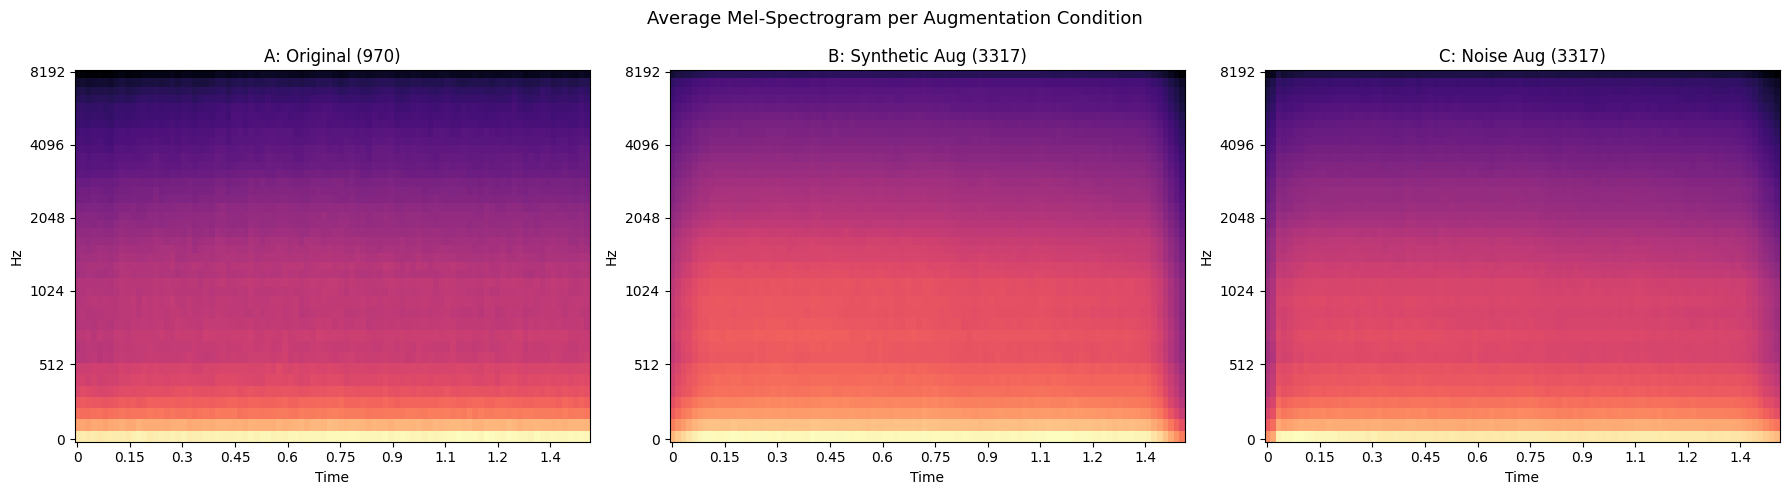

In [11]:
# Load all three conditions for comparison
orig_mel = np.load(str(MEL_DIR / 'train.npz'))['X']
synth_mel = np.load(str(MEL_DIR / 'train_augmented.npz'))['X']
noise_mel = mel_specs  # already in memory

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

conditions = [
    ('A: Original (970)', orig_mel),
    ('B: Synthetic Aug (3317)', synth_mel),
    ('C: Noise Aug ({})'.format(len(noise_mel)), noise_mel),
]

for ax, (title, data) in zip(axes, conditions):
    # Average mel-spectrogram across all samples
    avg = np.mean(data, axis=0)  # (40, 92)
    img = librosa.display.specshow(
        avg, sr=16000, hop_length=256,
        x_axis='time', y_axis='mel', fmin=20, fmax=8000,
        ax=ax, cmap='magma'
    )
    ax.set_title(title)

fig.suptitle('Average Mel-Spectrogram per Augmentation Condition', fontsize=13)
plt.tight_layout()
plt.show()

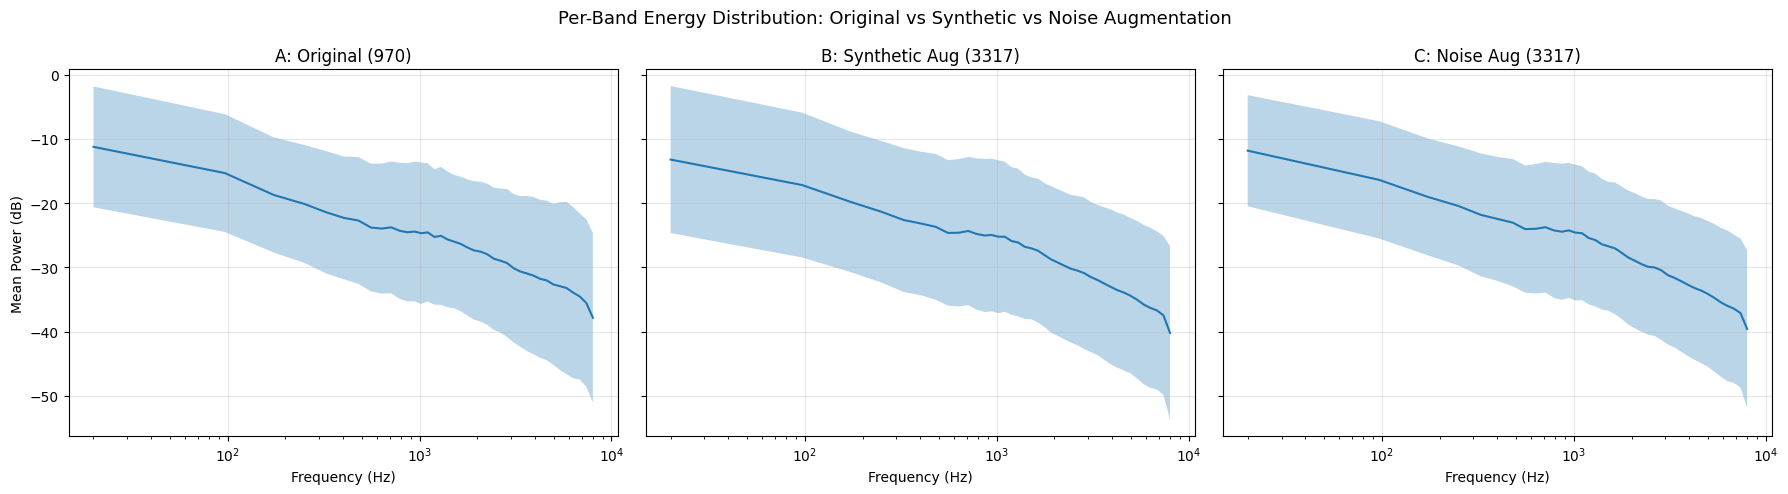

In [12]:
# Per-band energy distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
mel_freqs = librosa.mel_frequencies(n_mels=40, fmin=20, fmax=8000)

for ax, (title, data) in zip(axes, conditions):
    # Mean and std across samples and time
    band_mean = np.mean(data, axis=(0, 2))  # (40,)
    band_std = np.std(data, axis=(0, 2))    # (40,)
    ax.fill_between(mel_freqs, band_mean - band_std, band_mean + band_std, alpha=0.3)
    ax.plot(mel_freqs, band_mean, linewidth=1.5)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_xscale('log')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Mean Power (dB)')
fig.suptitle('Per-Band Energy Distribution: Original vs Synthetic vs Noise Augmentation', fontsize=13)
plt.tight_layout()
plt.show()

del orig_mel, synth_mel  # free memory

## 10. Save Augmentation Report

In [13]:
report = {
    'augmentation_type': 'noise_augmented',
    'description': 'Waveform augmentation + real-world noise injection using Arduino-collected noise bank',
    'original_train_size': n_orig,
    'augmented_samples_generated': total_aug,
    'final_train_size': n_orig + total_aug,
    'target_per_class': TARGET_PER_CLASS,
    'multipliers': {tier2_names[k]: v for k, v in multipliers.items()},
    'final_tier2_distribution': {
        tier2_names[i]: int((all_tier2 == i).sum()) for i in range(6)
    },
    'augmentation_techniques': [
        'time_shift (50% prob, +/-100ms)',
        'add_noise (50% prob, SNR 5-25 dB, Gaussian)',
        'pitch_shift (30% prob, +/-2 semitones)',
        'speed_perturb (30% prob, 0.9-1.1x)',
        'random_gain (50% prob, 0.7-1.3x)',
        'real_world_noise_injection (100% prob, SNR from [5, 10, 15, 20] dB)',
    ],
    'noise_bank': {
        'total_noise_samples': noise_config['total_samples'],
        'noise_groups': list(noise_bank.keys()),
        'group_counts': {g: len(a) for g, a in noise_bank.items()},
        'operational_state_mapping': noise_relevance,
        'snr_levels_db': snr_levels,
    },
    'output_files': [
        'data/features/mel_spectrograms/train_noise_augmented.npz',
        'data/features/mfcc/train_noise_augmented.npz',
        'data/normalization_stats_noise_augmented.npz',
    ],
    'random_state': RANDOM_STATE,
}

report_path = DATA_DIR / 'noise_augmentation_report.json'
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2)
print(f'Saved: {report_path.relative_to(PROJECT_ROOT)}')

Saved: data/noise_augmentation_report.json


## 11. Summary

In [14]:
print('=' * 65)
print('  Noise Augmentation Complete')
print('=' * 65)
print(f'\n  Training set: {n_orig} -> {n_orig + total_aug} samples')
print(f'  Noise bank: {noise_config["total_samples"]} real-world samples, {len(noise_bank)} groups')
print(f'  SNR levels: {snr_levels} dB')
print(f'\n  Output files:')
for f in report['output_files']:
    p = PROJECT_ROOT / f
    size = p.stat().st_size / (1024 * 1024)
    print(f'    {f} ({size:.1f} MB)')
print(f'    {report_path.relative_to(PROJECT_ROOT)}')
print(f'\n  Ablation conditions ready:')
print(f'    A: train.npz                   (970 samples, no augmentation)')
print(f'    B: train_augmented.npz          (3317 samples, synthetic aug only)')
print(f'    C: train_noise_augmented.npz    ({n_orig + total_aug} samples, synthetic + real noise)')
print(f'\n  Next step: train models on condition C and compare against A and B.')

  Noise Augmentation Complete

  Training set: 970 -> 3317 samples
  Noise bank: 360 real-world samples, 6 groups
  SNR levels: [5, 10, 15, 20] dB

  Output files:
    data/features/mel_spectrograms/train_noise_augmented.npz (40.6 MB)
    data/features/mfcc/train_noise_augmented.npz (14.1 MB)
    data/normalization_stats_noise_augmented.npz (0.0 MB)
    data/noise_augmentation_report.json

  Ablation conditions ready:
    A: train.npz                   (970 samples, no augmentation)
    B: train_augmented.npz          (3317 samples, synthetic aug only)
    C: train_noise_augmented.npz    (3317 samples, synthetic + real noise)

  Next step: train models on condition C and compare against A and B.
